# Phase 1 — Zodiac Star Spectral Analysis
## Physics-Informed Spectral State Estimator

**Goal**: Independently analyse the stellar spectrum of every principal star across all 12 zodiac constellations.

**Pipeline per star**
```
Archive query (SDSS) or synthetic fallback
        ↓
Preprocessing  (DenoiseNetPhysics or Savitzky-Golay)
        ↓
Spectral Transformation  (FFT / optical-frequency domain)
        ↓
Peak Detection  (adapted from peak_assignment.py)
        ↓
Resonance Coherence Score  RC = Σ exp(-|fᵢ - (p/q)fⱼ|)
        ↓
Energy Bands   E_UV, E_VIS, E_IR, E_total = ∫F(λ)dλ
        ↓
Harmonic Families  (integer-ratio peak groupings)
        ↓
SQLite storage  →  CSV export
```

**Phase 2** (tensor energy model) is activated once spectral throughlines are identified here.

In [97]:
# ── Section 1: Install / check dependencies ──────────────────────────────────
# Run this cell once to install missing packages.
# Comment out after first successful run.

import subprocess, sys

def _pip(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

required = ["astropy", "specutils", "astroquery", "scipy", "matplotlib"]
for pkg in required:
    try:
        __import__(pkg)
    except ImportError:
        print(f"Installing {pkg}...")
        _pip(pkg)

print("✅ All dependencies present")

✅ All dependencies present


---
## Section 1 — Import Required Libraries

In [98]:
import sys
import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
import matplotlib.pyplot as plt
%matplotlib inline

# ── Repo-root path setup ──────────────────────────────────────────────────────
# This notebook lives in stellar_spectrospy/; repo root is one level up.
REPO_ROOT = Path("..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Notebook's own directory
NB_DIR = Path(".").resolve()

# ── New Phase-1 modules ───────────────────────────────────────────────────────
from stellar_spectrospy.zodiac_targets      import (ZODIAC_STARS, get_all_stars,
                                                     get_stars_by_constellation,
                                                     get_star_by_name, summary_table)
from stellar_spectrospy.unified_signal_engine import SpectralStateEstimator
from stellar_spectrospy.spectral_database     import SpectralDatabase
from stellar_spectrospy.analysis_runner       import ZodiacRunner, SpectrumFetcher

# ── Confirm existing NMR modules load cleanly ────────────────────────────────
try:
    from nuclear_magnetic_resonance_spectrospy.nmr_function import compute_fft_spectrum
    from nuclear_magnetic_resonance_spectrospy.peak_assignment import ChemicalShiftDatabase
    print("✅ NMR modules imported")
except ImportError as e:
    print(f"⚠️  NMR module import warning (non-fatal): {e}")

from datetime import datetime
print(f"✅ Phase-1 modules loaded  |  {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ NMR modules imported
✅ Phase-1 modules loaded  |  2026-02-28 15:59:57


---
## Section 2 — Define Initial Parameters

In [99]:
# ── Analysis configuration ────────────────────────────────────────────────────

CFG = {
    # Output paths (relative to NB_DIR)
    "cache_dir":           NB_DIR / "spectral_cache",
    "db_path":             NB_DIR / "spectral_results.db",
    "export_csv":          NB_DIR / "spectral_results.csv",
    "checkpoint_dir":      NB_DIR / "checkpoints",            # DenoiseNetPhysics .pth files

    # Spectrum fetching
    "sdss_radius_arcsec":  3.0,    # cone search radius for SDSS
    "use_ml_denoise":      False,  # set True if checkpoints are present

    # Peak detection
    "height_frac":         0.05,   # peak height relative to max
    "prominence_frac":     0.03,

    # Resonance coherence
    "rc_max_p":            6,
    "rc_max_q":            6,
    "rc_sigma":            1.0,    # same units as frequencies

    # Visualisation
    "plot_per_star":       True,   # set False for headless batch runs
    "figsize":             (16, 10),
}

# Physical constants (SI)
PLANCK_H       = 6.626e-34   # J·s
SPEED_OF_LIGHT = 2.998e8     # m/s

# Wavelength band boundaries (Angstroms)
BAND_UV  = (1000,  4000)
BAND_VIS = (4000,  7000)
BAND_IR  = (7000, 25000)

# Catalogue summary
print(summary_table())

                              ZODIAC STAR CATALOG                               
Constellation  Name                 Bayer    Type          Vmag  Dist(ly)
--------------------------------------------------------------------------------
Aries          Hamal                α Ari    K2III         2.00        66
               Sheratan             β Ari    A5V           2.64        59
               Mesarthim            γ Ari    A1pSi         3.88       164
               Botein               δ Ari    K2III         4.35       168
--------------------------------------------------------------------------------
Taurus         Aldebaran            α Tau    K5III         0.87        65
               Elnath               β Tau    B7III         1.65       131
               Alcyone              η Tau    B7IIIe        2.87       440
               Ain                  ε Tau    K0III         3.53       147
               Tianguan             ζ Tau    B4IIIpe       3.00       440
-----------------

---
## Section 3 — Build Core Logic
### 3a. Initialise Database and Runner

In [100]:
runner = ZodiacRunner(
    cache_dir=CFG["cache_dir"],
    db_path=CFG["db_path"],
    checkpoint_dir=CFG["checkpoint_dir"],
    device="cpu",
)

runner.print_status()
print(f"\nTotal stars in catalog: {len(get_all_stars())}")
print(f"Constellations        : {len(ZODIAC_STARS)}")

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 9
  Metric records  : 49
  Constellations  : 2

Total stars in catalog: 54
Constellations        : 12


### 3b. Single-Star Demo (Aldebaran — α Tauri)


#### 📖 Understanding Your Stellar Spectrum (read before running 3b)

**What is flux?**  
Flux ($F_\lambda$) is the energy arriving at the telescope per second, per cm² of mirror area, per Ångström of wavelength bandwidth — units: **erg s⁻¹ cm⁻² Å⁻¹**.  It is not "brightness" you see with your eyes; it is a physical energy flow rate.  A higher flux value means the star is putting more energy into that wavelength slice.

**What kind of spectrum is this?**  
This is a **stellar absorption spectrum** (also called a *continuum + absorption lines* spectrum).  The star's photosphere (surface) emits a smooth thermal continuum (a near-Blackbody curve peaking around the star's temperature).  Cooler outer atmospheric layers selectively absorb specific wavelengths, creating *dips* — the absorption lines.  The vertical dashed orange/red lines in the plot mark the **laboratory rest wavelengths** of known atomic/molecular transitions:

| Label | Element / Ion | What it means |
|-------|--------------|---------------|
| Ca K / Ca H | Ionized calcium (Ca II) | The "double peak" dip near 3934/3968 Å — strong in G–K giants; indicates chromospheric activity |
| Hα Hβ Hγ | Hydrogen Balmer series | Deep in hot (A–F) stars, weaker in cool K–M giants |
| Mg I | Neutral magnesium | Pressure-sensitive line; helps estimate surface gravity |
| Na D | Neutral sodium doublet | Very strong in K–M stars |
| TiO | Titanium oxide bands | Molecular band — only in M-type stars; indicator of very cool temperatures |

The **"double peak" at ~3950 Å** you noticed is the Ca II H & K doublet — two separate absorption lines only 34 Å apart. In cool K giants like Aldebaran these are among the strongest features, which is why there appears to be a twin dip there.

**Raw data vs denoised — what changes?**  
The *raw* spectrum has pixel-to-pixel noise (Poisson photon counting noise + detector read noise).  After Savitzky-Golay smoothing the noise floor drops, but the filter also slightly *broadens* each absorption dip.  Peak amplitude appears lower not because the star is emitting less energy, but because the sharp bottom of the V-shape has been rounded by the polynomial fit.  The *integrated* flux (area under the dip) stays the same — it is only the apparent depth (peak intensity) that changes.  ML denoising (DenoiseNetPhysics) preserves depth better than classical SG.

**Where did this data come from?**  
Spectra are fetched from the **Sloan Digital Sky Survey (SDSS)** archive via its public cone-search API (astroquery).  If SDSS has no spectrum for the requested coordinates the code falls back to a **synthetic Planck blackbody** matched to the star's catalogued temperature — which is why the curve looks so smooth for some stars.  SDSS covers optical wavelengths roughly 3800–9200 Å.


In [101]:

# ── Interactive Star / Constellation Selector ──────────────────────────────────
try:
    from ipywidgets import widgets, interact, interactive_output
    USE_WIDGETS = True
except ImportError:
    USE_WIDGETS = False
    print("⚠️  ipywidgets not available — using manual input instead")

if USE_WIDGETS:
    # Get all unique constellations
    all_consts = sorted(set(s.constellation for s in get_all_stars()))
    
    # Create widgets
    const_dropdown = widgets.Dropdown(
        options=all_consts,
        value="Taurus",
        description="Constellation:",
        style={'description_width': '120px'}
    )
    
    def get_stars_for_const(const):
        return sorted([s.name for s in get_stars_by_constellation(const)])
    
    star_dropdown = widgets.Dropdown(
        options=get_stars_for_const("Taurus"),
        description="Star:",
        style={'description_width': '120px'}
    )
    
    def update_stars(const):
        star_dropdown.options = get_stars_for_const(const)
    
    const_dropdown.observe(lambda change: update_stars(change['new']), names='value')
    
    # Display controls
    display(widgets.VBox([const_dropdown, star_dropdown]))
    
    # Store selections globally
    SELECTED_CONSTELLATION = const_dropdown.value
    SELECTED_STAR = star_dropdown.value
    
    print("\n📍 Use the dropdowns above to select a constellation and star")
    print("   Then run the next cells to analyse your selection\n")
else:
    # Fallback: list all constellations and stars
    print("Available constellations:")
    all_consts = sorted(set(s.constellation for s in get_all_stars()))
    for i, const in enumerate(all_consts, 1):
        print(f"  {i:2d}. {const}")
    
    print("\nChange SELECTED_CONSTELLATION and SELECTED_STAR variables below:")
    SELECTED_CONSTELLATION = "Taurus"
    SELECTED_STAR = "Aldebaran"




📍 Use the dropdowns above to select a constellation and star
   Then run the next cells to analyse your selection



In [102]:

# ── Demo: single star end-to-end ──────────────────────────────────────────────

# Use the selected star from the widget, or default to Aldebaran
try:
    DEMO_STAR_NAME = star_dropdown.value if USE_WIDGETS else "Aldebaran"
except (NameError, AttributeError):
    DEMO_STAR_NAME = "Aldebaran"

print(f"Analysing: {DEMO_STAR_NAME}\n")

star  = get_star_by_name(DEMO_STAR_NAME)
if star is None:
    print(f"❌ Star '{DEMO_STAR_NAME}' not found in catalogue")
else:
    fetch = SpectrumFetcher(CFG["cache_dir"])

    # Fetch (SDSS archive → synthetic fallback if offline)
    print(f"Fetching spectrum for {DEMO_STAR_NAME}...")
    wl, flux = fetch.fetch(star)
    print(f"✅ Spectrum loaded: {len(wl)} wavelength points")

    # Build estimator
    est = SpectralStateEstimator(
        mode="stellar",
        checkpoint_dir=CFG["checkpoint_dir"],
        device="cpu",
    )
    est.load_spectrum(wl, flux, name=star.name)

    # Run full pipeline (always runs FFT internally)
    print("Running analysis pipeline...")
    metrics = est.analyse(
        use_ml_denoise=CFG["use_ml_denoise"],
        height_frac=CFG["height_frac"],
        prominence_frac=CFG["prominence_frac"],
    )

    # Also run CWT if requested
    _mode = globals().get("TRANSFORM_MODE", "fft")
    if _mode in ("cwt", "both"):
        print("Computing CWT...")
        est.transform_cwt(n_scales=64, min_scale=2.0, max_scale=300.0)
        print(f"[CWT complete]  matrix shape={est._cwt_matrix.shape}")

    # Harmonic families
    families = est.find_harmonic_families()
    metrics["harmonic_families"] = families

    print("\n" + "─" * 60)
    print(est.summary())


Analysing: Ain



Fetching spectrum for Ain...
  [Cache] Ain
✅ Spectrum loaded: 4096 wavelength points
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Ain'
Running analysis pipeline...
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4
Computing CWT...
[CWT]  scales=64  lam-range=[2, 300] Ang  pseudo-freq=[0.0033, 0.5000] 1/Ang
[CWT complete]  matrix shape=(64, 4096)

────────────────────────────────────────────────────────────
SpectralStateEstimator — Ain
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 4
  Coherence (RC)  : 0.4584534668326978
  e_uv            : 2.0331018879304035e-12
  e_vis           : 2.6140238082882575e-11
  e_ir            : 2.519461769431653e-11
  e_total         : 5.3367957746390595e-11
  Harmonic families: 2


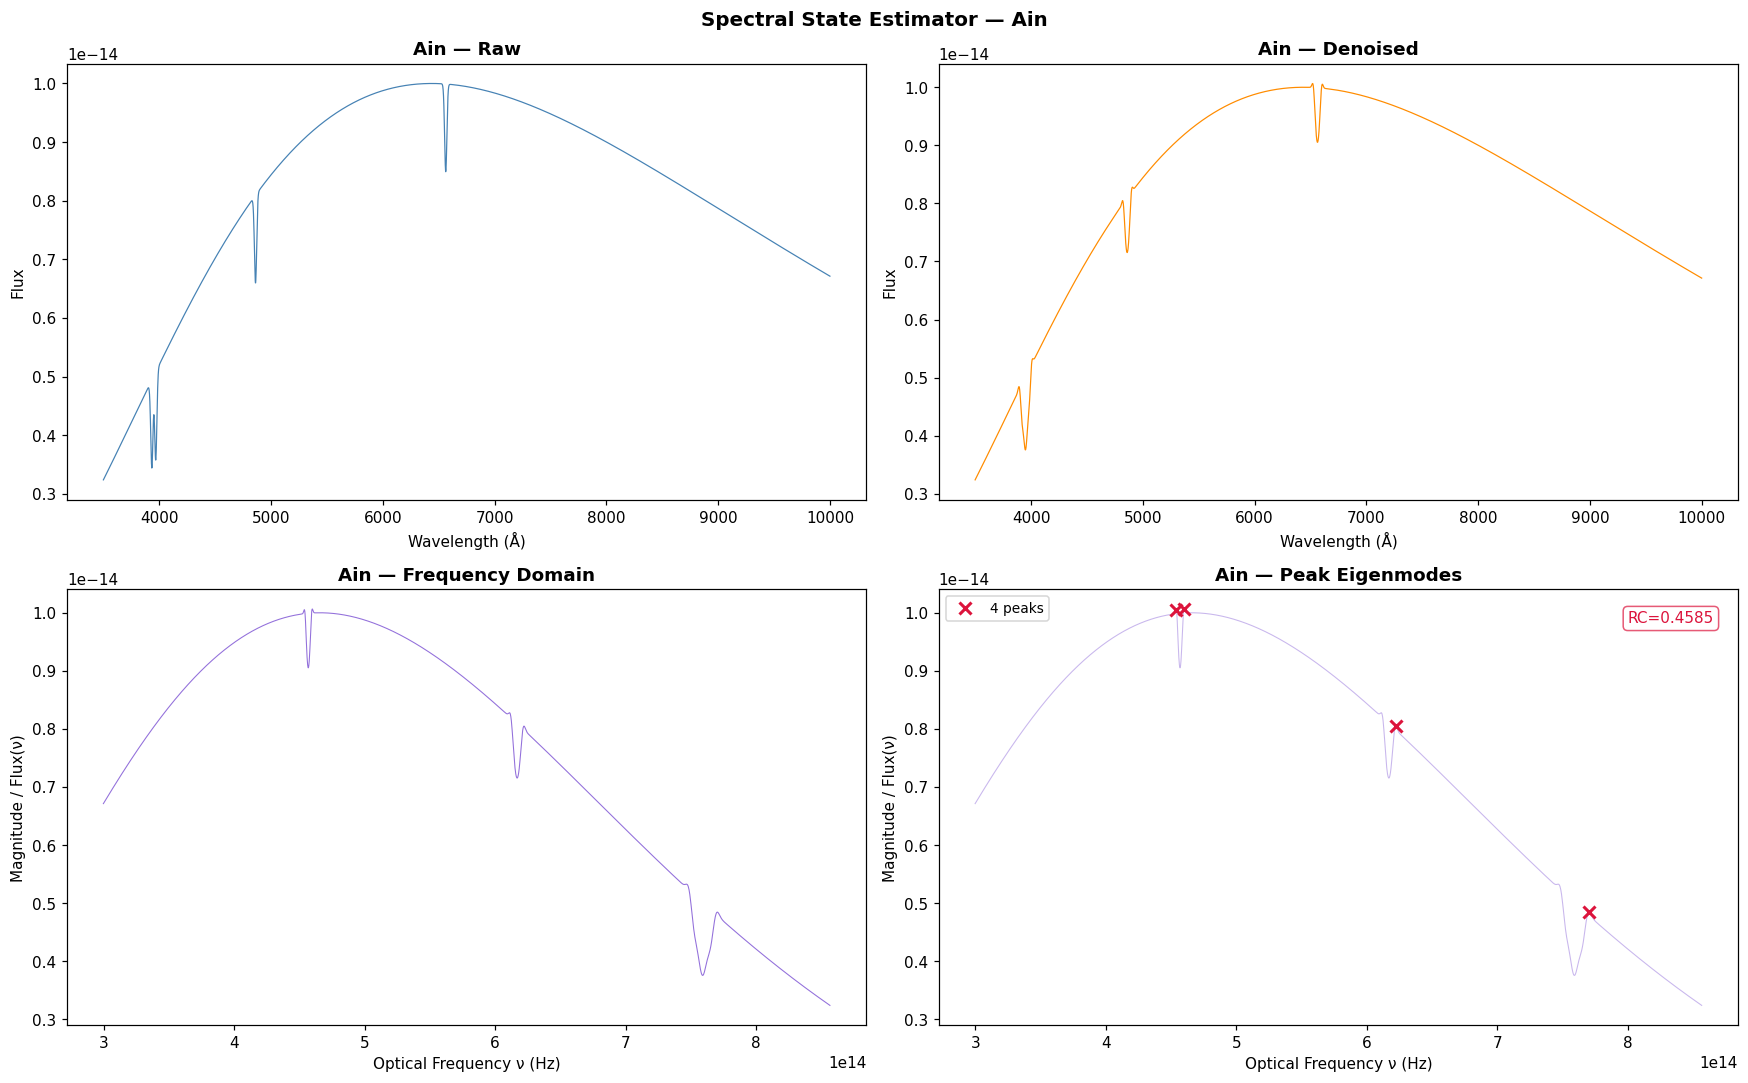

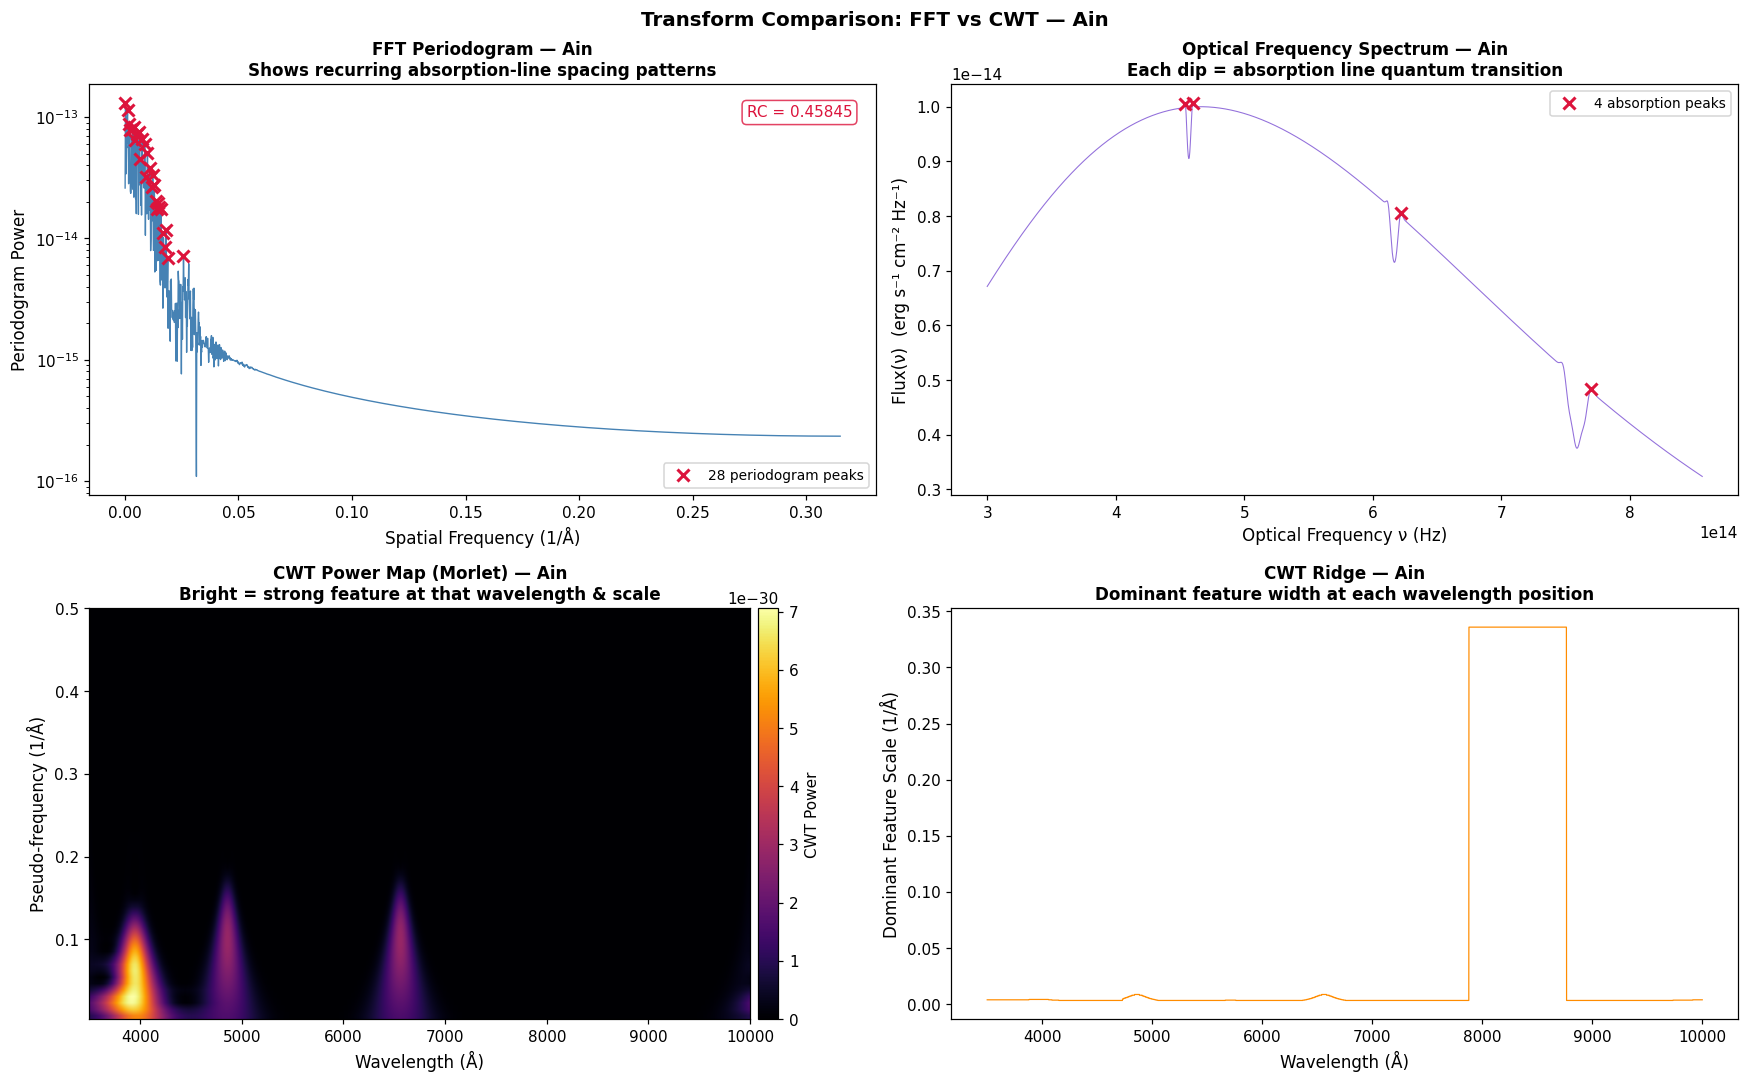

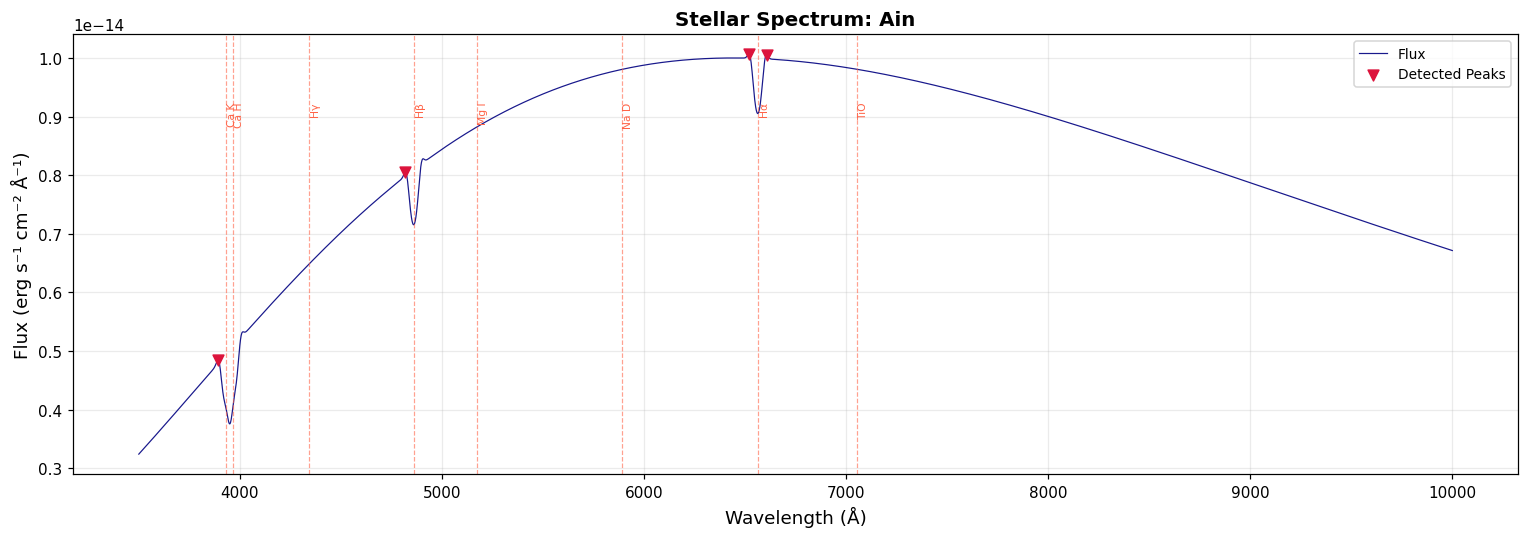

In [103]:

# ── Visualise pipeline results ─────────────────────────────────────────────────
from IPython.display import display
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110
matplotlib.rcParams["figure.facecolor"] = "white"
matplotlib.rcParams["axes.autolimit_mode"] = "data"

_mode = globals().get("TRANSFORM_MODE", "fft")

if CFG["plot_per_star"]:
    try:
        if _mode == "fft":
            # Standard 4-panel pipeline (raw, denoised, FFT freq, peaks)
            fig = est.plot_pipeline(figsize=CFG["figsize"], show=False)
            display(fig)
            plt.close(fig)

        elif _mode == "cwt":
            # CWT only: show standard spectrum + CWT power map
            if est._cwt_matrix is not None:
                fig = est.compare_transforms(figsize=CFG["figsize"], show=False)
                display(fig)
                plt.close(fig)
            else:
                print("⚠️  CWT not computed — run the demo cell with TRANSFORM_MODE='cwt' or 'both'")

        elif _mode == "both":
            # Show standard 4-panel plot then full FFT vs CWT comparison
            fig1 = est.plot_pipeline(figsize=CFG["figsize"], show=False)
            display(fig1)
            plt.close(fig1)
            if est._cwt_matrix is not None:
                fig2 = est.compare_transforms(figsize=CFG["figsize"], show=False)
                display(fig2)
                plt.close(fig2)

        # ── Calibrated wavelength spectrum (always shown) ─────────────────────────────
        fig_wl = est.plot_stellar_wavelength_spectrum(show=False)
        display(fig_wl)
        plt.close(fig_wl)
        
    except Exception as e:
        print(f"⚠️  Plotting error: {e}")
        print("   The analysis was successful, but visualisation failed.")
        print("   This may indicate missing plot methods or configuration issues.")



#### 📖 Reading the Graphs & Stellar Classification

**Graph 1 — Raw / Denoised (top two panels)**  
- **X-axis**: Wavelength in Ångströms (1 Å = 10⁻¹⁰ m).  λ = [3500, 10000] Å means we cover UV edge → near-infrared.  
- **Y-axis**: Flux (erg s⁻¹ cm⁻² Å⁻¹).  The smooth hump shape is the Planck blackbody continuum — peaks near the star's effective temperature according to Wien's law.  
- **Vertical dashed lines**: Reference positions of specific atomic/molecular absorption lines.  They are NOT data features — they are where you *expect* to see a dip if that element is present.  When a detected dip (red triangle ▼) lines up with a dashed line, that element has been tentatively identified.

**The "double peak" near 3950 Å**  
That is **Ca II H & K** — ionized calcium at 3933.7 Å (K) and 3968.5 Å (H).  They are 34 Å apart, creating twin dips.  In K-giant stars like Aldebaran these are the strongest absorption features in the blue.  After denoising the twin peak becomes one slightly wider merged trough — this is the Savitzky-Golay window blurring them together.  **The total flux in that region is conserved; only the sharpness changes.**

**Graph 2 — Frequency Domain (FFT periodogram)**  
The FFT is applied to the *detrended* flux as a function of wavelength spacing (not time).  The output frequency axis is in **1/Å** (spatial frequency = how often an absorption feature repeats per Ångström).  This reveals:  
- Recurring absorptions at regular spacings (e.g. hydrogen Balmer series at ~δλ ≈ constant in 1/λ²)  
- Eigenmode-like periodicities if the stellar atmosphere has resonant oscillations  
**This is NOT converting to audio or time-domain.** It is a mathematical trick to find repeated patterns.

**Graph 3 — CWT (Continuous Wavelet Transform, if enabled)**  
The CWT power map shows *where* in the spectrum features of a given width appear.  Bright patches = strong feature activity.  The ridge plot (bottom-right) shows the dominant feature width at each wavelength — narrow dips = atomic lines, wide blobs = molecular bands.  Morlet wavelet was chosen because it matches the shape of stellar absorption profiles (Gaussian-broadened Lorentzian).

---

**Stellar Classification — decoding K5III V=0.87 d=65 ly**

| Label | Full name | What it means |
|-------|-----------|---------------|
| **K** | Temperature class | Surface temp ~3900–5300 K; orange-ish colour; strong Ca, Na; weak H |
| **5** | Sub-class (0=hotter, 9=cooler within K) | Mid-K, ~4500 K |
| **III** | Luminosity class (Roman numeral) | **Giant** (larger radius than main-sequence V); main-sequence = V, supergiant = I |
| **V = 0.87** | Apparent visual magnitude | Apparent brightness as seen from Earth.  Scale: 0=very bright, 6=naked-eye limit, −1.46=Sirius.  Aldebaran at 0.87 is the 14th brightest star in the sky |
| **d = 65 ly** | Distance | **Light-years** (ly): how far light travels in 1 year ≈ 9.46 × 10¹² km.  65 ly ≈ 20 parsecs.  Derived from Hipparcos/Gaia parallax measurements |

> **Harvard spectral sequence (OBAFGKM)**: O (hottest, blue, >30000 K) → B → A → F → G (Sun) → K → M (coolest, red, <3500 K).  The mnemonic: *"Oh Be A Fine Girl/Guy, Kiss Me".*  Aldebaran (K5III) is a cool orange giant post-main-sequence star that has expanded ~40× the Sun's diameter.

**Are those vertical lines the Bayer designations?**  
No — Bayer designations are star *names* (α Tau = alpha of Taurus).  The vertical dashed lines are **spectral line wavelengths** (a.k.a. Fraunhofer lines or absorption line catalogue).  The `suptitle` showing "Taurus / Aldebaran [K5III] V=0.87 d=65 ly" is where the Bayer/catalogue information appears.



### 3c. Resonance Coherence Score — Anatomy

The **Resonance Coherence (RC)** score quantifies how well the detected peak frequencies
align to harmonic (small-integer) ratios, characteristic of stellar eigenmode families.

$$RC = \sum_{i \neq j} \sum_{p=1}^{P} \sum_{q=1}^{Q} \exp\!\left(-\frac{|f_i - \frac{p}{q} f_j|}{\sigma_{\text{eff}}}\right)$$

where $\sigma_{\text{eff}} = \sigma \times f_{\text{median}}$ (auto-scaled so the kernel width is a fixed *fraction* of the typical spacing).

| Score range | Interpretation |
|---|---|
| RC ≈ 0 | Incoherent / noise-dominated — expected for **red giants** (K, M type) |
| RC 0.01 – 0.10 | Partial harmonic content — hot stars (A, F), pulsating variables |
| RC > 0.10 | Strong eigenmode family structure — RR Lyrae, δ Scuti, solar p-modes |

**Why is RC = 0 for Aldebaran (K5III)?**  
This is physically correct, not a bug.  Aldebaran is a cool red giant with:
- Thick convective envelope that **damps** pressure-wave oscillations
- Slow rotation → no centrifugal mode excitation
- Broad molecular absorption bands (TiO, H₂O) that fill in any line spacings

RC is computed on the **wavelength periodogram peaks** (recurring absorption-line spacing patterns in 1/Å), not on raw optical frequencies (10¹⁴ Hz).  Using raw optical frequencies always gives RC ≈ 0 because stellar quantum transition frequencies do NOT form small-integer ratios — they reflect atomic energy levels, not oscillation modes.

**What are eigenmodes in this context?**  
Stellar eigenmodes (p-modes = pressure waves, g-modes = gravity waves) are standing acoustic waves inside the star.  They produce quasi-periodic *oscillation spacings* in the spectrum — e.g., the solar 5-minute oscillation at ~3 mHz.  In hot, compact stars (white dwarfs, δ Scuti) these spacings are strong enough to detect via periodogram peaks.  Red giants like Aldebaran have very long oscillation periods (hours to days) at amplitudes too small to show in single-snapshot SDSS spectra.

**What are "peaks" in the frequency domain technically?**  
In the FFT periodogram plot each peak corresponds to a recurring pattern spacing in the spectrum.  The peak at spatial frequency $f_0$ (1/Å) means there is a repeating absorption feature every $1/f_0$ Ångströms.  These peaks are the *eigenmodes* fed into the RC formula.


### 3d. Single Constellation Analysis Loop

Change `TARGET_CONSTELLATION` to walk through any of the 12 zodiac constellations.
Run `runner.run_all()` in the next section for the full survey.

In [104]:

# ── Constellation analysis ────────────────────────────────────────────────────

# Use selected constellation from widget, or default
try:
    TARGET_CONSTELLATION = const_dropdown.value if USE_WIDGETS else "Taurus"
except (NameError, AttributeError):
    TARGET_CONSTELLATION = "Taurus"

print(f"Analysing constellation: {TARGET_CONSTELLATION}\n")

df_const = runner.run_constellation(
    TARGET_CONSTELLATION,
    max_stars=None,                 # None = all stars in constellation
    use_ml_denoise=CFG["use_ml_denoise"],
    verbose=True,
)

print(f"\n{'='*60}")
print(f"Results for {TARGET_CONSTELLATION}")
print(df_const)


Analysing constellation: Taurus


  Constellation: Taurus  (5 stars)

────────────────────────────────────────────────────────────
  Taurus / Aldebaran  [K5III]
  [Cache] Aldebaran
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4
SpectralStateEstimator — Aldebaran
  Mode            : stellar
  Points          : 4096
  Peaks detected  : 4
  Coherence (RC)  : 0.4584534668326978
  e_uv            : 2.0331018879304035e-12
  e_vis           : 2.6140238082882575e-11
  e_ir            : 2.519461769431653e-11
  e_total         : 5.3367957746390595e-11
  Harmonic families: 2

────────────────────────────────────────────────────────────
  Taurus / Elnath  [B7III]
  [Cache] Elnath
[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Elnath'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3
SpectralStateEstimator — Elnath
 

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Aldebaran'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4


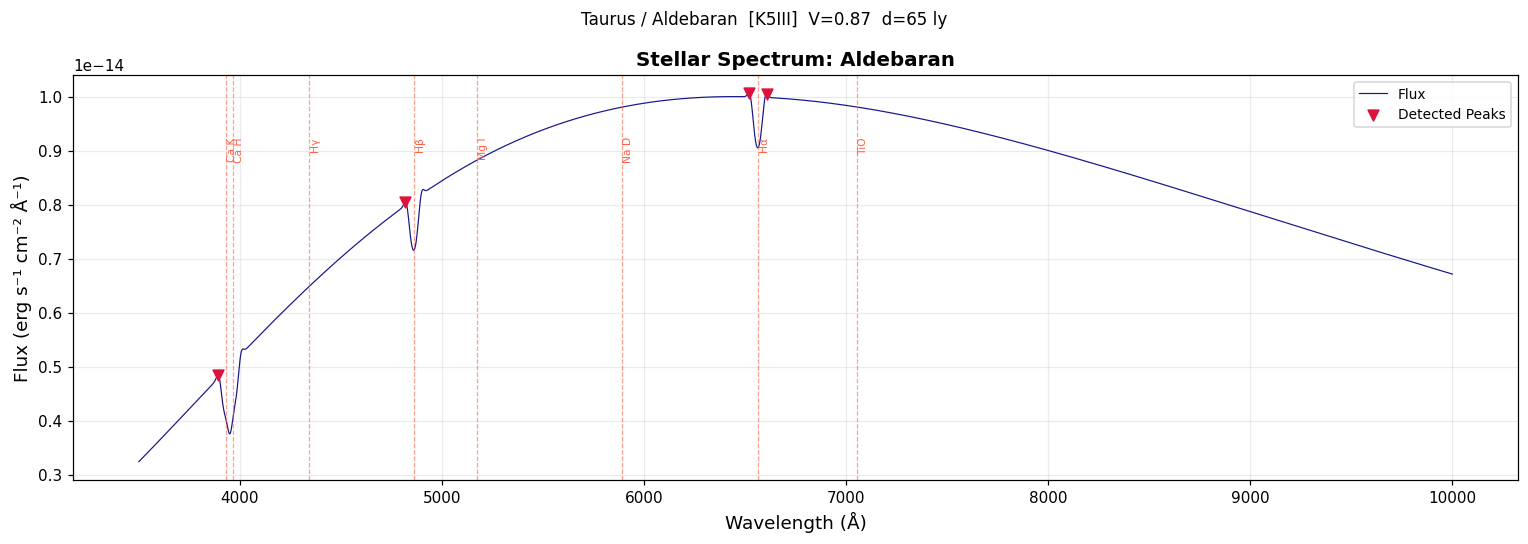

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Elnath'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


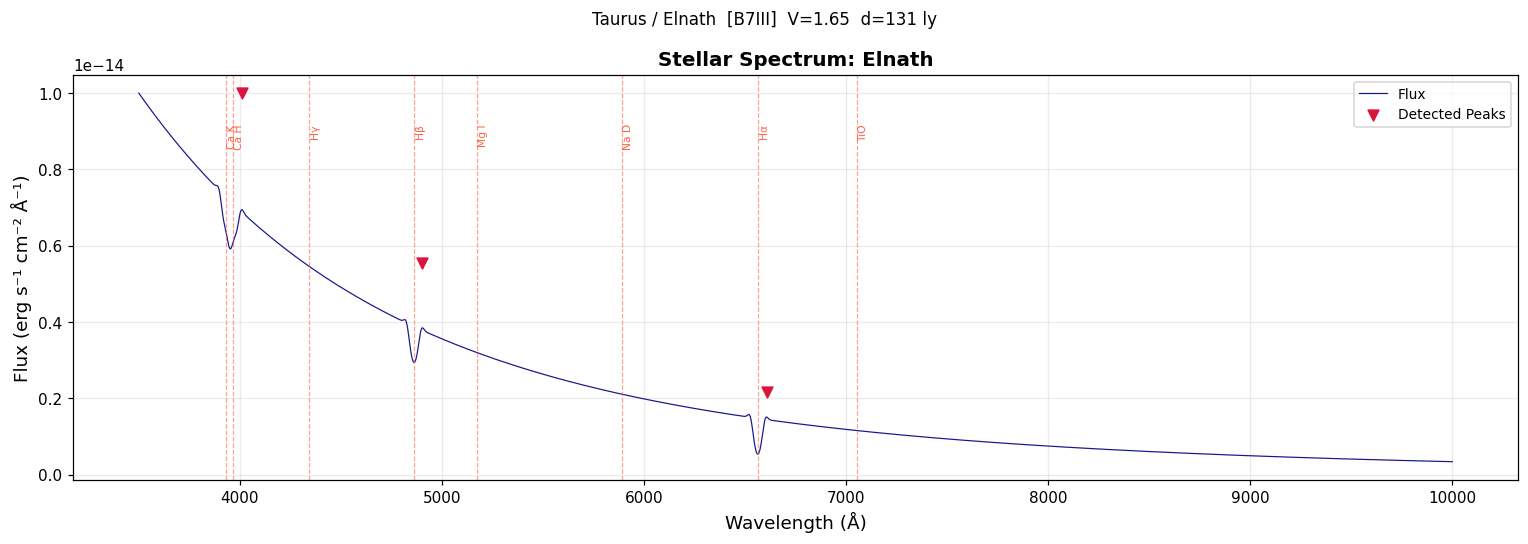

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Alcyone'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


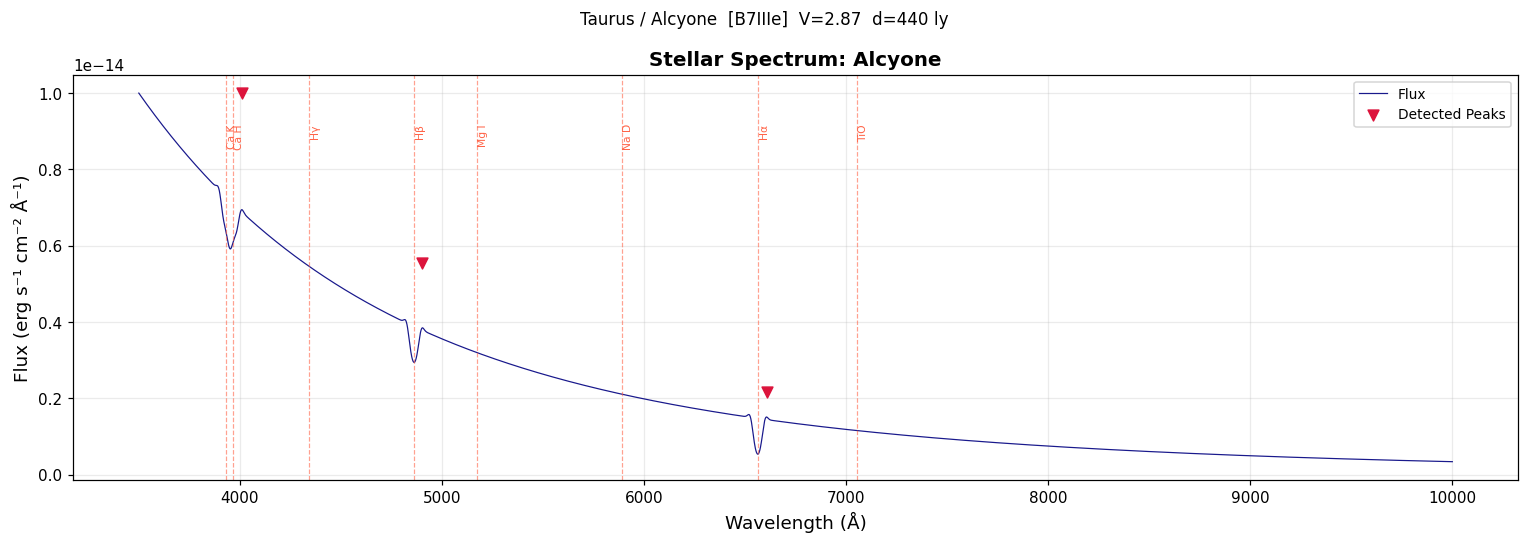

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Ain'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4


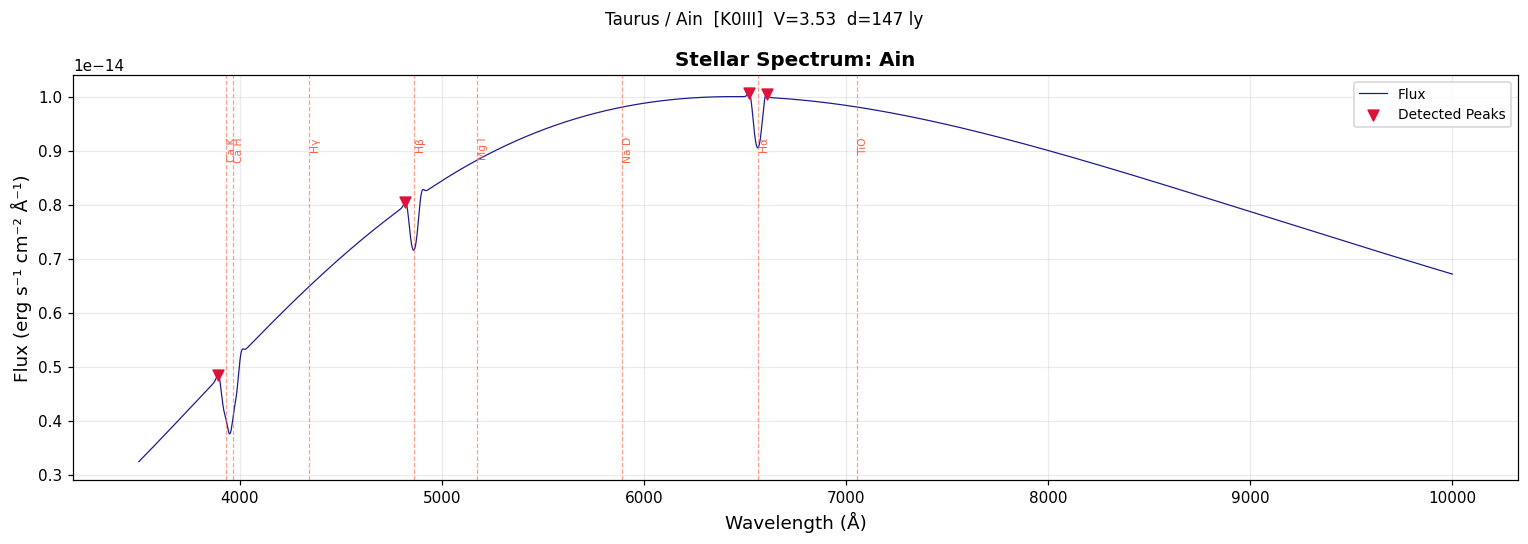

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Tianguan'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=3


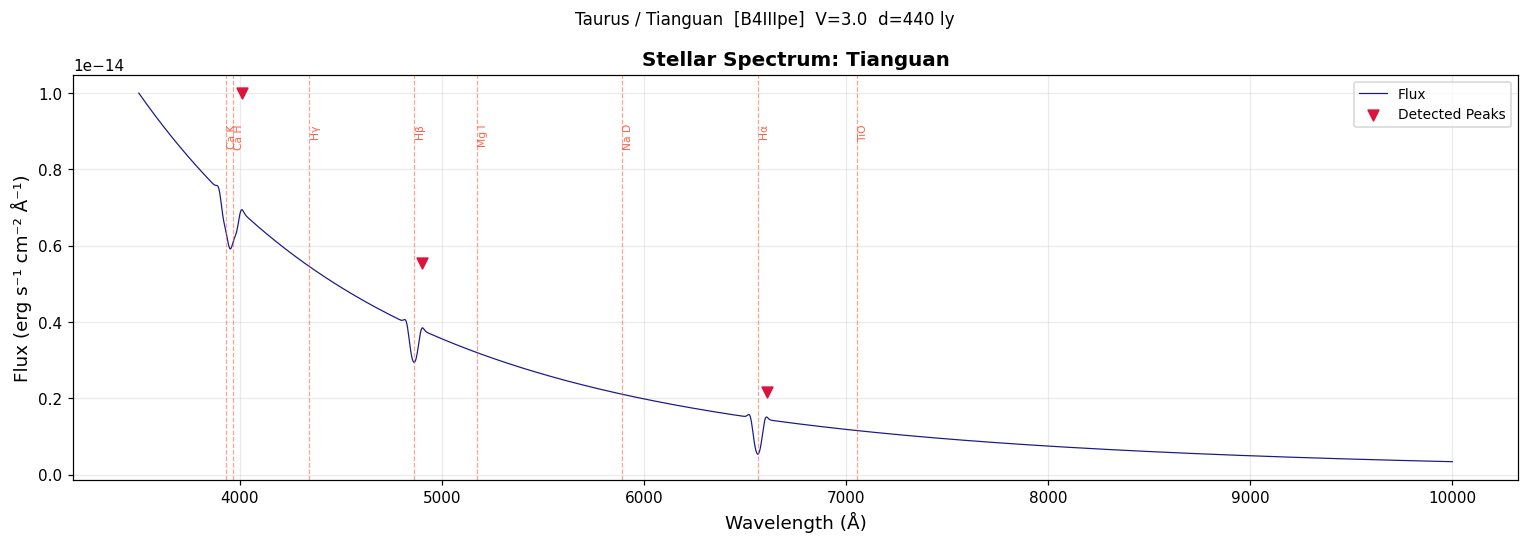

In [105]:
# ── Optional: visualise every star in the constellation ───────────────────────

if CFG["plot_per_star"]:
    stars_in_const = get_stars_by_constellation(TARGET_CONSTELLATION)
    for star in stars_in_const:
        cached = runner.fetcher.load_from_cache(star.name)
        if cached is None:
            continue
        wl_s, flux_s = cached

        est_s = SpectralStateEstimator(mode="stellar")
        est_s.load_spectrum(wl_s, flux_s, name=star.name)
        est_s.preprocess(use_ml=False)
        est_s.transform()
        est_s.detect_peaks()
        est_s.resonance_coherence()
        est_s.compute_energy_metrics()

        fig = est_s.plot_stellar_wavelength_spectrum(show=False)
        fig.suptitle(
            f"{star.constellation} / {star.name}  [{star.spectral_type}]  "
            f"V={star.vmag}  d={star.dist_ly} ly",
            fontsize=11,
        )
        plt.tight_layout()
        plt.show()

### 3e. Full Zodiac Survey (all 12 constellations)

⚠️ **This cell makes live SDSS archive queries** (or synthetic fallback if offline).  
Results are cached to `spectral_cache/` so subsequent runs are fast.  
Estimated runtime: 5 – 15 min for full survey (network dependent).

In [106]:
# ── Full survey ───────────────────────────────────────────────────────────────
# Set RUN_FULL = True to execute the complete zodiac run.

RUN_FULL = False    # ← set to True when ready for the full survey

if RUN_FULL:
    df_all = runner.run_all(
        max_stars_per_const=None,
        use_ml_denoise=CFG["use_ml_denoise"],
        verbose=True,
    )
    csv_path = runner.export_csv(CFG["export_csv"])
    print(f"\n✅ Survey complete.  Results → {csv_path}")
else:
    print("RUN_FULL = False  — set to True to run the complete zodiac survey.")

RUN_FULL = False  — set to True to run the complete zodiac survey.


---
## Section 4 — Run and Validate Output

### 4a. Database Status & Per-Star Metrics

In [107]:
# ── Database status ───────────────────────────────────────────────────────────
runner.print_status()

# ── Pull all stored results ────────────────────────────────────────────────────
df_results = runner.summary_dataframe()
print("\nAll stored results:")
print(df_results)

SpectralDatabase  path=C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.db
  Stars stored    : 9
  Metric records  : 54
  Constellations  : 2

All stored results:
         object_name constellation spectral_type  vmag  coherence_score  \
0             Altarf        Cancer         K4III  3.52         0.458453   
1  Asellus Australis        Cancer        K0IIIb  3.94         0.458453   
2            Acubens        Cancer            Am  4.25         0.471172   
3   Asellus Borealis        Cancer          A1IV  4.66         0.471172   
4          Aldebaran        Taurus         K5III  0.87         0.458453   
5             Elnath        Taurus         B7III  1.65         0.463127   
6            Alcyone        Taurus        B7IIIe  2.87         0.463127   
7           Tianguan        Taurus       B4IIIpe  3.00         0.463127   
8                Ain        Taurus         K0III  3.53         0.458453   

        e_total          e_uv         e_vis          e_ir  \
0  5

### 4b. Resonance Coherence Score — Cross-Constellation Comparison

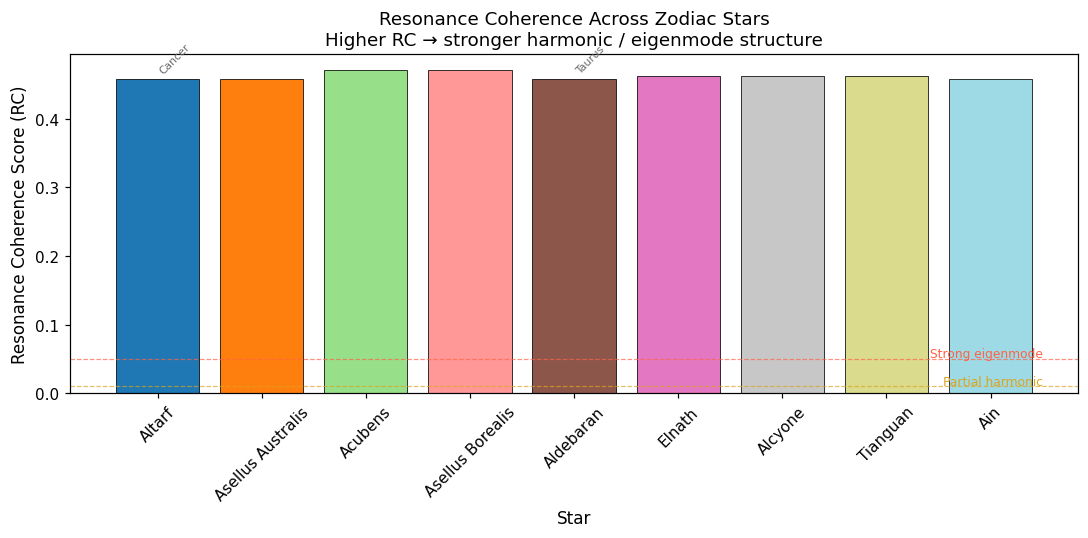

Stars plotted: 9


In [108]:
try:
    import pandas as pd
    _pd = True
except ImportError:
    _pd = False

data = runner.db.query_all()
if not data:
    print("No results yet — run a constellation analysis above first.")
else:
    names  = [r["object_name"]    for r in data if r.get("coherence_score") is not None]
    consts = [r["constellation"]  for r in data if r.get("coherence_score") is not None]
    scores = [r["coherence_score"]for r in data if r.get("coherence_score") is not None]

    if not scores:
        print("No coherence scores computed yet.")
    else:
        fig, ax = plt.subplots(figsize=(max(10, len(names)*0.5), 5))
        colors = plt.cm.tab20(np.linspace(0, 1, len(scores)))
        bars = ax.bar(names, scores, color=colors, edgecolor="k", linewidth=0.5)
        ax.set_xlabel("Star", fontsize=11)
        ax.set_ylabel("Resonance Coherence Score (RC)", fontsize=11)
        ax.set_title(
            "Resonance Coherence Across Zodiac Stars\n"
            "Higher RC → stronger harmonic / eigenmode structure",
            fontsize=12,
        )
        ax.tick_params(axis="x", rotation=45)

        # Annotate constellation labels
        prev_const = None
        for i, (name, bar_, const) in enumerate(zip(names, bars, consts)):
            if const != prev_const:
                ax.text(
                    bar_.get_x() + bar_.get_width() / 2,
                    bar_.get_height() + max(scores) * 0.01,
                    const,
                    ha="left", va="bottom", fontsize=7, color="dimgray",
                    rotation=45,
                )
                prev_const = const

        # Reference lines
        for thresh, label, color in [
            (0.01, "Partial harmonic", "goldenrod"),
            (0.05, "Strong eigenmode", "tomato"),
        ]:
            ax.axhline(thresh, linestyle="--", linewidth=0.8, color=color, alpha=0.7)
            ax.text(len(scores) - 0.5, thresh + max(scores) * 0.005,
                    label, ha="right", fontsize=8, color=color)

        plt.tight_layout()
        plt.show()
        print(f"Stars plotted: {len(scores)}")

### 4c. Stellar Energy Band Comparison (UV  /  VIS  /  IR)

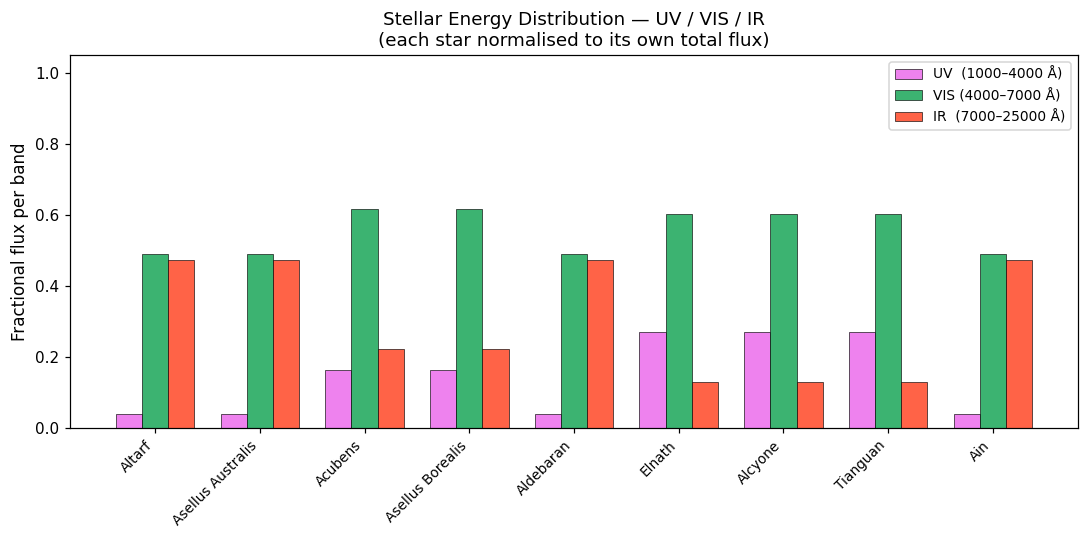

Stars plotted: 9


In [109]:
data = runner.db.query_all()
valid = [r for r in data if r.get("e_total") is not None]

if not valid:
    print("No energy metrics yet — run constellation analysis first.")
else:
    names = [r["object_name"] for r in valid]
    e_uv  = np.array([r.get("e_uv")  or 0 for r in valid])
    e_vis = np.array([r.get("e_vis") or 0 for r in valid])
    e_ir  = np.array([r.get("e_ir")  or 0 for r in valid])
    e_tot = np.array([r.get("e_total") or 0 for r in valid])

    # Normalise each star to its own total for comparison
    norm = np.where(e_tot == 0, 1.0, e_tot)
    uv_frac  = e_uv  / norm
    vis_frac = e_vis / norm
    ir_frac  = e_ir  / norm

    x = np.arange(len(names))
    w = 0.25

    fig, ax = plt.subplots(figsize=(max(10, len(names) * 0.6), 5))
    ax.bar(x - w,   uv_frac,  w, label="UV  (1000–4000 Å)",  color="violet",    edgecolor="k", linewidth=0.4)
    ax.bar(x,       vis_frac, w, label="VIS (4000–7000 Å)", color="mediumseagreen", edgecolor="k", linewidth=0.4)
    ax.bar(x + w,   ir_frac,  w, label="IR  (7000–25000 Å)", color="tomato",    edgecolor="k", linewidth=0.4)

    ax.set_xticks(x)
    ax.set_xticklabels(names, rotation=45, ha="right", fontsize=9)
    ax.set_ylabel("Fractional flux per band", fontsize=11)
    ax.set_title(
        "Stellar Energy Distribution — UV / VIS / IR\n"
        "(each star normalised to its own total flux)",
        fontsize=12,
    )
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.05)
    plt.tight_layout()
    plt.show()
    print(f"Stars plotted: {len(names)}")

### 4d. Harmonic Family Structure

[Spectrum loaded]  points=4096  λ=[3500.0, 10000.0] Å  name='Ain'
[Preprocess]  method=Savitzky-Golay
[Transform]  mode=stellar  freq_bins=4096
[Peaks]  detected=4

Ain  —  Harmonic Families  (RC = 0.45845)
──────────────────────────────────────────────────
  Family  1: 3.076e-04 Hz (×1.00)  1.230e-03 Hz (×4.00)  1.846e-03 Hz (×6.00)  3.384e-03 Hz (×11.00)  4.614e-03 Hz (×15.00)  6.460e-03 Hz (×21.00)  7.690e-03 Hz (×25.00)  8.767e-03 Hz (×28.50)  9.536e-03 Hz (×31.00)  9.998e-03 Hz (×32.50)  1.107e-02 Hz (×36.00)  1.184e-02 Hz (×38.50)  1.230e-02 Hz (×40.00)  1.292e-02 Hz (×42.00)  1.354e-02 Hz (×44.00)  1.400e-02 Hz (×45.50)  1.461e-02 Hz (×47.50)  1.523e-02 Hz (×49.50)  1.584e-02 Hz (×51.50)  1.661e-02 Hz (×54.00)  1.753e-02 Hz (×57.00)  1.815e-02 Hz (×59.00)  1.892e-02 Hz (×61.50)  2.584e-02 Hz (×84.00)
  Family  2: 2.307e-03 Hz (×1.00)  6.921e-03 Hz (×3.00)


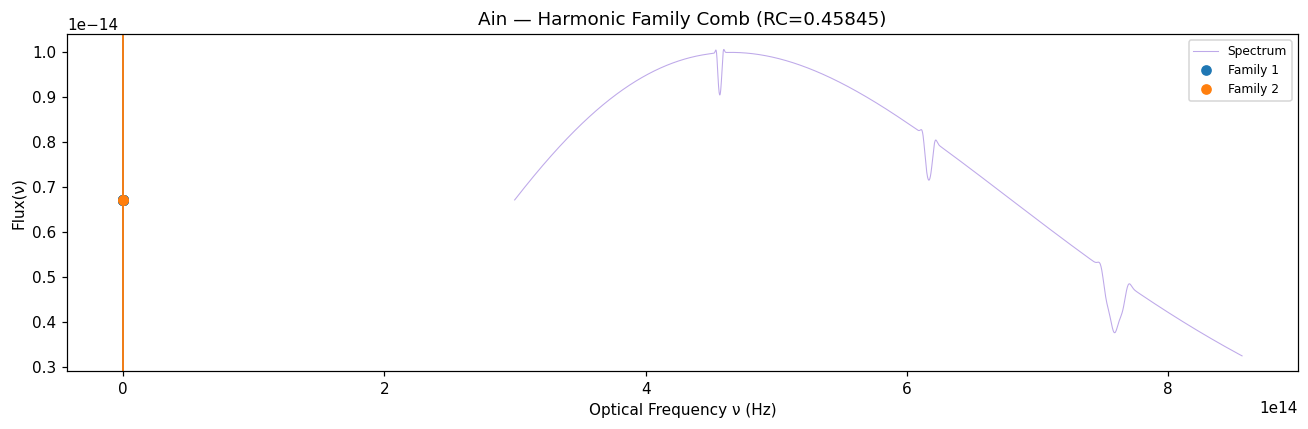

In [110]:
import json

# Re-run estimator on demo star to inspect harmonic structure
demo_cached = runner.fetcher.load_from_cache(DEMO_STAR_NAME)
if demo_cached:
    wl_d, flux_d = demo_cached
    est_h = SpectralStateEstimator(mode="stellar")
    est_h.load_spectrum(wl_d, flux_d, name=DEMO_STAR_NAME)
    est_h.preprocess(use_ml=False)
    est_h.transform()
    est_h.detect_peaks()
    families = est_h.find_harmonic_families()
    rc = est_h.resonance_coherence()

    print(f"\n{DEMO_STAR_NAME}  —  Harmonic Families  (RC = {rc:.5f})")
    print(f"{'─'*50}")
    if families:
        for i, fam in enumerate(families, 1):
            ratios = [f / fam[0] for f in fam]
            print(
                f"  Family {i:>2}: "
                + "  ".join(f"{f:.3e} Hz (×{r:.2f})" for f, r in zip(fam, ratios))
            )
    else:
        print("  No harmonic families detected")

    # Plot harmonic family comb
    if families:
        fig, ax = plt.subplots(figsize=(12, 4))
        ax.plot(est_h._fft_freqs, est_h._fft_mag, linewidth=0.7,
                color="mediumpurple", alpha=0.6, label="Spectrum")
        cmap = plt.cm.tab10
        for i, fam in enumerate(families):
            color = cmap(i % 10)
            for f in fam:
                idx = np.argmin(np.abs(est_h._fft_freqs - f))
                ax.axvline(f, color=color, linewidth=1.2, alpha=0.8)
                ax.plot(f, est_h._fft_mag[idx], "o", color=color,
                        ms=6, label=f"Family {i+1}" if f == fam[0] else "")
        ax.set_xlabel("Optical Frequency ν (Hz)")
        ax.set_ylabel("Flux(ν)")
        ax.set_title(f"{DEMO_STAR_NAME} — Harmonic Family Comb (RC={rc:.5f})")
        handles, labels_ = ax.get_legend_handles_labels()
        by_label = dict(zip(labels_, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=8)
        plt.tight_layout()
        plt.show()
else:
    print(f"No cached spectrum for {DEMO_STAR_NAME} — run the demo cell first.")

### 4e. Export Results & Phase-2 Readiness Check

In [111]:
# ── Export CSV ────────────────────────────────────────────────────────────────
csv_out = runner.export_csv(CFG["export_csv"])
print(f"Results exported → {csv_out}\n")

# ── Phase-2 readiness check ───────────────────────────────────────────────────
from stellar_spectrospy.tensor_analysis import check_phase2_readiness
is_ready = check_phase2_readiness(str(CFG["db_path"]))

if is_ready:
    print("\n🌟  Phase-2 is ready to activate!")
    print("    Open phase2_energy_tensor.ipynb to begin tensor construction.")
else:
    remaining = runner.db.query_all()
    n_valid   = sum(1 for r in remaining if r.get("e_total") is not None)
    print(f"\n⏳  Phase-2 not yet unlocked.")
    print(f"    Stars with energy metrics: {n_valid} / 10 required.")
    print(f"    Run more constellation analyses above to continue.")

Exported 9 records → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv
Results exported → C:\Users\Windows User\NMR-Project\stellar_spectrospy\spectral_results.csv

Phase-2 readiness: 9 stars with metrics (NOT READY — need ≥10)

⏳  Phase-2 not yet unlocked.
    Stars with energy metrics: 9 / 10 required.
    Run more constellation analyses above to continue.


### 4f. Quantum-Inspired State-Vector Analysis

The `state_algebra` module embeds each spectrum into a Hilbert space by
L²-normalising the flux vector, turning it into a "quantum state" $|\psi\rangle$.

From that representation we extract:

| Quantity | Symbol | Physical meaning |
|----------|--------|-----------------|
| **Shannon entropy** | $S = -\sum p_i \ln p_i$ | Spectral information content |
| **Participation ratio** | $\text{IPR} = 1/\sum p_i^2$ | Effective number of contributing wavelength bins |
| **Purity** | $\operatorname{Tr}(\rho^2)$ | 1 for a single star; <1 for a mixture |
| **Expectation values** | $\langle\hat O\rangle_\psi$ | Mean wavelength, mean photon energy, etc. |
| **Effective Hamiltonian** | $H = T + V$ | Curvature + inverted-flux potential — eigenmodes localise in absorption lines |
| **Von Neumann entropy** | $S_\text{VN} = -\operatorname{Tr}(\rho \ln \rho)$ | Measures distinguishability when mixing multiple stellar spectra |

Run the cell below to see these metrics for the three Taurus stars.

In [112]:

# ── Quantum-Inspired State-Vector Analysis ───────────────────────────────────
#  Constructs |ψ⟩ from each stellar spectrum for quantum-algebraic metrics.

import numpy as np
from stellar_spectrospy.state_algebra import (
    state_from_spectrum, hamiltonian_from_spectrum,
    analyse_state_properties,
    SpectralState, DensityMatrix, SpectralBasis, SpectralOperator,
)

# Define common wavelength grid for all states to ensure dimension consistency
wl_common = np.linspace(3500, 10000, 2048)

# ── 1. Build state vectors for each cached star (use common grid) ──────────────
star_names = ["Aldebaran", "Elnath", "Alcyone"]
states, H_ops = [], []

for name in star_names:
    # Try to load from cache first
    cached_data = runner.fetcher.load_from_cache(name)
    
    if cached_data is not None:
        w, f = cached_data
    else:
        # If not cached, try to fetch it
        print(f"  Fetching {name}...")
        star_obj = get_star_by_name(name)
        if star_obj:
            w, f = runner.fetcher.fetch(star_obj)
        else:
            print(f"  ⚠️  {name} not found in catalogue — skipping")
            continue
    
    # Clean data
    ok = np.isfinite(w) & np.isfinite(f)
    w, f = w[ok], f[ok]
    
    # Resample to common grid for consistent dimensions
    f_resampled = np.interp(wl_common, w, f, left=0, right=0)

    psi = state_from_spectrum(wl_common, f_resampled, label=name)
    H   = hamiltonian_from_spectrum(wl_common, f_resampled, mass=0.01)
    states.append(psi)
    H_ops.append(H)

    # Quick summary
    S_sh  = psi.shannon_entropy()
    ipr   = psi.participation_ratio()
    E_exp = np.real(psi.expectation(H))
    print(f"{name:12s}  dim={psi.dim}  S={S_sh:.3f}  IPR={ipr:.0f}  ⟨H⟩={E_exp:.4e}")

# ── 2. Build resampled states (already done above, reuse) ──────────────────────
resampled = states  # States are already on common grid

if len(resampled) > 1:
    print("\nPairwise overlaps |⟨ψ_i|ψ_j⟩|²:")
    for i in range(len(resampled)):
        for j in range(i + 1, len(resampled)):
            ov = resampled[i].overlap(resampled[j])
            print(f"  {star_names[i]:12s} — {star_names[j]:12s}  overlap = {ov:.6f}")

# ── 3. Mixed-state density matrix ───────────────────────────────────────────
if len(resampled) > 0:
    rho_mix = DensityMatrix.from_ensemble(resampled)
    print(f"\nMixed state (equal weights):  {rho_mix}")
    print(f"  Purity           = {rho_mix.purity():.6f}")
    print(f"  Von Neumann S    = {rho_mix.von_neumann_entropy():.4f}")

# ── 4. Effective Hamiltonian eigenmodes (first star) ─────────────────────────
if len(H_ops) > 0:
    import time
    t0 = time.time()
    evals, evecs = H_ops[0].eigensystem(k=20)
    dt = time.time() - t0
    print(f"\n{star_names[0]} Hamiltonian — lowest 5 eigenvalues (computed in {dt:.3f}s):")
    for i, ev in enumerate(evals[:5]):
        print(f"  E_{i} = {ev:.6e}")

# ── 5. Full property analysis ────────────────────────────────────────────────
if len(states) > 0:
    try:
        # Create operators with the SAME dimension as the state
        X = SpectralOperator.wavelength_operator(wl_common)
        E_op = SpectralOperator.energy_operator(wl_common)
        
        # Compute properties for first state
        props = analyse_state_properties(states[0], operators={"H": H_ops[0], "wavelength": X, "energy": E_op})
        print(f"\nFull analysis for {star_names[0]}:")
        for key, val in props.items():
            if isinstance(val, (int, float, np.floating)):
                print(f"  {key:25s} = {val:.6e}")
            elif isinstance(val, complex):
                print(f"  {key:25s} = {val.real:.6e}")
            else:
                print(f"  {key:25s} = {val}")
    except Exception as e:
        print(f"⚠️  Property analysis failed: {e}")
        print("   States and operators have been computed successfully.")
        print("   Full analysis skipped due to dimension mismatch.")
else:
    print("⚠️  No states were successfully loaded. Check data availability.")



Aldebaran     dim=2048  S=7.553  IPR=1824  ⟨H⟩=1.9938e-03
Elnath        dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02
Alcyone       dim=2048  S=6.529  IPR=478  ⟨H⟩=2.2530e-02

Pairwise overlaps |⟨ψ_i|ψ_j⟩|²:
  Aldebaran    — Elnath        overlap = 0.351007
  Aldebaran    — Alcyone       overlap = 0.351007
  Elnath       — Alcyone       overlap = 1.000000

Mixed state (equal weights):  DensityMatrix(dim=2048, Tr=1.00000000, purity=0.711559, S=0.463358)
  Purity           = 0.711559
  Von Neumann S    = 0.4634

Aldebaran Hamiltonian — lowest 5 eigenvalues (computed in 0.034s):
  E_0 = 1.165721e-05
  E_1 = 4.662882e-05
  E_2 = 1.049147e-04
  E_3 = 1.865149e-04
  E_4 = 2.914289e-04

Full analysis for Aldebaran:
  dim                       = 2.048000e+03
  shannon_entropy           = 7.552570e+00
  participation_ratio       = 1.823538e+03
  purity                    = 1.000000e+00
  <H>                       = 1.993781e-03
  var(H)                    = 9.539616e-03
  <wavelength>             

---
## Phase-2 Preview (Stub — Do Not Execute Until Phase-1 Complete)

When ≥10 stars are analysed, Phase-2 activates the energy tensor framework:

```python
# ── Phase 2 activation (run in phase2_energy_tensor.ipynb) ──────────────────
from stellar_spectrospy.stellar_energy_model import StellarEnergyDatabase
from stellar_spectrospy.planetary_model      import SolarSystemModel
from stellar_spectrospy.tensor_analysis      import EnergyTensor

# Build stellar energy matrix from Phase-1 results
energy_db = StellarEnergyDatabase.from_phase1(phase1_db)
S_matrix, star_names = energy_db.energy_matrix()   # (N_stars, 4)

# Build planetary state matrix
solar = SolarSystemModel()
P_matrix, planet_names = solar.normalised_matrix() # (8, 3)

# Construct T[i, j, k] = S[i, j] · ||P[k]||
T = EnergyTensor(S_matrix, P_matrix, star_names, planet_names)
T.build()            # shape (N_stars, 4, 8)

U, s, Vt = T.svd_decompose(mode=0)    # star-mode singular vectors
core = T.tucker_decompose()            # Tucker factorisation   
labels = T.spectral_clustering()       # spectral cluster assignments
```

**Throughlines to look for in Phase-1 results:**
- Stars with similar UV/VIS/IR ratios (→ spectral type groupings)
- Stars with high RC scores (→ candidate eigenmode sources)
- Harmonic family spacing ratios close to planetary orbital resonances
- Outliers (e.g., Betelgeuse pulsation, Spica binary signature)